<h1>Mental Health Crisis Predicter

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('Mental Health Dataset.csv')
print(df.head())
print(f"Shape of the dataset: {df.shape}")

         Timestamp  Gender        Country Occupation self_employed  \
0  8/27/2014 11:29  Female  United States  Corporate           NaN   
1  8/27/2014 11:31  Female  United States  Corporate           NaN   
2  8/27/2014 11:32  Female  United States  Corporate           NaN   
3  8/27/2014 11:37  Female  United States  Corporate            No   
4  8/27/2014 11:43  Female  United States  Corporate            No   

  family_history treatment Days_Indoors Growing_Stress Changes_Habits  \
0             No       Yes    1-14 days            Yes             No   
1            Yes       Yes    1-14 days            Yes             No   
2            Yes       Yes    1-14 days            Yes             No   
3            Yes       Yes    1-14 days            Yes             No   
4            Yes       Yes    1-14 days            Yes             No   

  Mental_Health_History Mood_Swings Coping_Struggles Work_Interest  \
0                   Yes      Medium               No            No   


In [2]:
#print(df.isna().sum())
# Only Self_Employed has Nan, we will fill it by Mode
df.drop_duplicates(inplace=True)
print(f"MODE:",df['self_employed'].mode()[0])
df['self_employed'].fillna('No', inplace=True)
print(df.isna().sum())


MODE: No
Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64


C:\Users\MLS\AppData\Local\Temp\ipykernel_2648\3408747316.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['self_employed'].fillna('No', inplace=True)


<h1>Encoding

In [3]:
#print(df.dtypes)
df.drop(columns=['Timestamp','Country'],inplace=True)

In [4]:
# Mapping
binary_map={'Yes':1,'No':0}
tri_map={'Yes':1,'No':0,'Maybe':0.5}
mood_map={'Low':0,'Medium':1,'High':2}
days_map   = {
    'Go out Every day'   : 0,
    '1-14 days'          : 1,
    '15-30 days'         : 2,
    '31-60 days'         : 3,
    'More than 2 months' : 4
}
care_map   = {'No': 0, 'Not sure': 0.5, 'Yes': 1}

df['Gender']                  = df['Gender'].map({'Male':1,'Female':0})
df['self_employed']           = df['self_employed'].map(binary_map)
df['family_history']          = df['family_history'].map(binary_map)
df['treatment']               = df['treatment'].map(binary_map)
df['Growing_Stress']          = df['Growing_Stress'].map(tri_map)
df['Changes_Habits']          = df['Changes_Habits'].map(tri_map)
df['Mental_Health_History']   = df['Mental_Health_History'].map(tri_map)
df['Mood_Swings']             = df['Mood_Swings'].map(mood_map)
df['Coping_Struggles']        = df['Coping_Struggles'].map(binary_map)
df['Work_Interest']           = df['Work_Interest'].map(tri_map)
df['Social_Weakness']         = df['Social_Weakness'].map(tri_map)
df['mental_health_interview'] = df['mental_health_interview'].map(tri_map)
df['care_options']            = df['care_options'].map(care_map)
df['Days_Indoors']            = df['Days_Indoors'].map(days_map)

# Label_encoding
le = LabelEncoder()
df['Occupation'] = le.fit_transform(df['Occupation'])
print(df.dtypes)

Gender                       int64
Occupation                   int64
self_employed                int64
family_history               int64
treatment                    int64
Days_Indoors                 int64
Growing_Stress             float64
Changes_Habits             float64
Mental_Health_History      float64
Mood_Swings                  int64
Coping_Struggles             int64
Work_Interest              float64
Social_Weakness            float64
mental_health_interview    float64
care_options               float64
dtype: object


<h1>Feature_Engineering

In [5]:
corr = df.drop('treatment', axis=1).corrwith(df['treatment']).abs().sort_values(ascending=False)
print(corr.round(4))

family_history             0.3647
care_options               0.2506
Gender                     0.1781
mental_health_interview    0.0667
self_employed              0.0364
Coping_Struggles           0.0102
Growing_Stress             0.0074
Occupation                 0.0040
Work_Interest              0.0032
Mood_Swings                0.0028
Changes_Habits             0.0020
Mental_Health_History      0.0013
Days_Indoors               0.0007
Social_Weakness            0.0004
dtype: float64


In [6]:

# GROUP 1 — Stress Score

df['stress_score'] = (
    df['Growing_Stress'] +     
    df['Mood_Swings'] +        
    df['Coping_Struggles']     
)

# GROUP 2 — Behavioral Score 
df['behavioral_score'] = (
    df['Changes_Habits'] +   
    df['Work_Interest'] +      
    df['Social_Weakness'] +  
    df['Days_Indoors']  
)

# GROUP 3 — Awareness Score
df['awareness_score'] = (
    df['Mental_Health_History'] +    
    df['mental_health_interview'] +  
    df['care_options']               
)

# family_history sabse strong hai — is liye isko multoply kya
df['stress_x_family']    = df['stress_score']    * df['family_history']
df['care_x_family']      = df['care_options']    * df['family_history']
df['awareness_x_family'] = df['awareness_score'] * df['family_history']
df['gender_x_stress']    = df['Gender']          * df['stress_score']

# RISK FLAG (if this is 1 , then it is an alarming situation)
df['high_risk_flag'] = (
    (df['stress_score']     >= 3) &
    (df['behavioral_score'] >= 4) &
    (df['family_history']   == 1)
).astype(int)

# VERIFY
print("NEW columns:")
print(df[['stress_score','behavioral_score','awareness_score',
          'stress_x_family','care_x_family',
          'awareness_x_family','gender_x_stress',
          'high_risk_flag']].head())

print("\nDataset New_shape:", df.shape)


NEW columns:
   stress_score  behavioral_score  awareness_score  stress_x_family  \
0           2.0               2.0              1.5              0.0   
1           2.0               2.0              1.0              2.0   
2           2.0               2.0              2.0              2.0   
3           2.0               2.0              2.5              2.0   
4           2.0               2.0              2.0              2.0   

   care_x_family  awareness_x_family  gender_x_stress  high_risk_flag  
0            0.0                 0.0              0.0               0  
1            0.0                 1.0              0.0               0  
2            1.0                 2.0              0.0               0  
3            1.0                 2.5              0.0               0  
4            1.0                 2.0              0.0               0  

Dataset New_shape: (290051, 23)


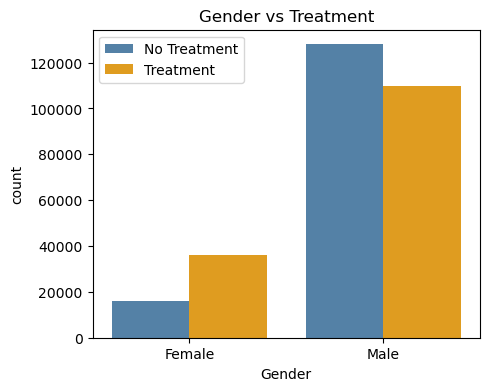

In [25]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Gender', hue='treatment', data=df, 
              palette=['steelblue', 'orange'])
plt.title('Gender vs Treatment')
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(['No Treatment', 'Treatment'])
plt.show()

<h3>As we can see Male are the ones that are in higher numbers and also there ratio is high to the 'No Treatement'

<h2>Training MODELs

In [7]:

X = df.drop('treatment', axis=1)
y = df['treatment']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,      
    stratify     = y         # class balance maintain karne ke liye
)

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print()
print("Training mein class distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print()
print("Testing mein class distribution:")
print(y_test.value_counts(normalize=True).round(3) * 100)

X_train shape: (232040, 22)
X_test shape: (58011, 22)

Training mein class distribution:
treatment
1    50.4
0    49.6
Name: proportion, dtype: float64

Testing mein class distribution:
treatment
1    50.4
0    49.6
Name: proportion, dtype: float64


<h1>MODELS</h1>
<h2>1. Logistic_Regression

In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)
 
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.67      0.68     28774
           1       0.69      0.72      0.70     29237

    accuracy                           0.69     58011
   macro avg       0.69      0.69      0.69     58011
weighted avg       0.69      0.69      0.69     58011



<h2>2. Random_Forrest

In [9]:


rf_model = RandomForestClassifier(
    n_estimators = 150,   # 100 trees
    random_state = 42,
    n_jobs       = -1     # saare CPU cores use karo — fast hoga
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.63      0.67     28774
           1       0.67      0.74      0.70     29237

    accuracy                           0.69     58011
   macro avg       0.69      0.69      0.69     58011
weighted avg       0.69      0.69      0.69     58011



<h2>3. XG_Boost

In [15]:


xgb_model = XGBClassifier(
    n_estimators    = 300,    # 100 se badha ke 300
    max_depth       = 6,      # tree kitna deep jaye
    learning_rate   = 0.05,   # slowly seekhe — better results
    subsample       = 0.8,    # har tree 80% data dekhe
    colsample_bytree= 0.8,    # har tree 80% features dekhe
    random_state    = 42,
    eval_metric     = 'logloss',
    n_jobs          = -1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.66      0.70     28774
           1       0.70      0.76      0.73     29237

    accuracy                           0.71     58011
   macro avg       0.71      0.71      0.71     58011
weighted avg       0.71      0.71      0.71     58011



<h2>4. KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)  # scaled data chahiye
y_pred_knn = knn_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))

=== KNN ===
Accuracy: 64.98 %
              precision    recall  f1-score   support

           0       0.65      0.65      0.65     28774
           1       0.65      0.65      0.65     29237

    accuracy                           0.65     58011
   macro avg       0.65      0.65      0.65     58011
weighted avg       0.65      0.65      0.65     58011



<h2>5. Gradient_Boosting

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators  = 200,
    learning_rate = 0.05,
    max_depth     = 5,
    random_state  = 42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(classification_report(y_test, y_pred_gb))

=== GRADIENT BOOSTING ===
Accuracy: 71.42 %
              precision    recall  f1-score   support

           0       0.73      0.67      0.70     28774
           1       0.70      0.76      0.73     29237

    accuracy                           0.71     58011
   macro avg       0.72      0.71      0.71     58011
weighted avg       0.72      0.71      0.71     58011



In [ ]:
xgb_model.fit(X_train, y_train)      
y_pred_xgb = xgb_model.predict(X_test)   

voting_model = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, eval_metric='logloss', n_jobs=-1)),
        ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                            max_depth=5, random_state=42))
    ],
    voting='soft'
)
voting_model.fit(X_train, y_train) 
y_pred_voting = voting_model.predict(X_test)

print("=== VOTING CLASSIFIER ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_voting) * 100, 2), "%")
print(classification_report(y_test, y_pred_voting))

=== VOTING CLASSIFIER ===
Accuracy: 71.54 %
              precision    recall  f1-score   support

           0       0.73      0.67      0.70     28774
           1       0.70      0.76      0.73     29237

    accuracy                           0.72     58011
   macro avg       0.72      0.72      0.71     58011
weighted avg       0.72      0.72      0.71     58011



<h2>Confusion Matrix of Votting_Regressor

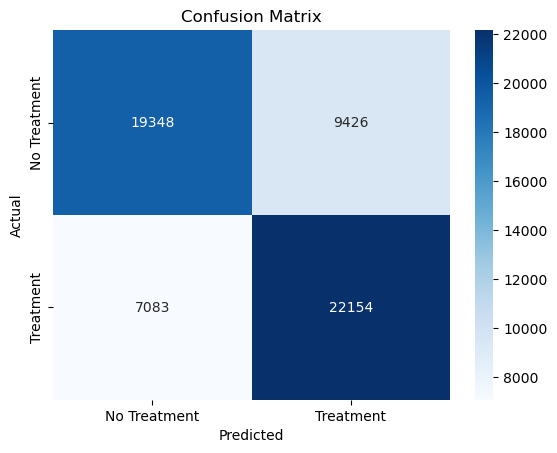

In [17]:

cm = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Treatment','Treatment'],
            yticklabels=['No Treatment','Treatment'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<h2>Feature Importance

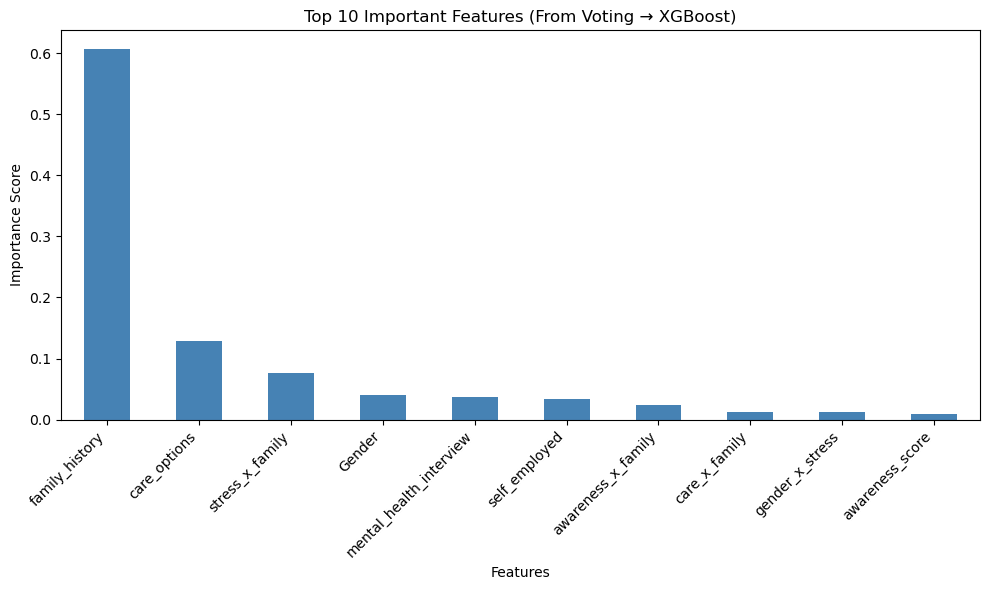

In [18]:
# Voting model ke andar se XGBoost access ker rahy hy
xgb_from_voting = voting_model.named_estimators_['xgb']

feat_imp = pd.Series(
    xgb_from_voting.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features (From Voting → XGBoost)')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h2>Model Accuracy Comparison

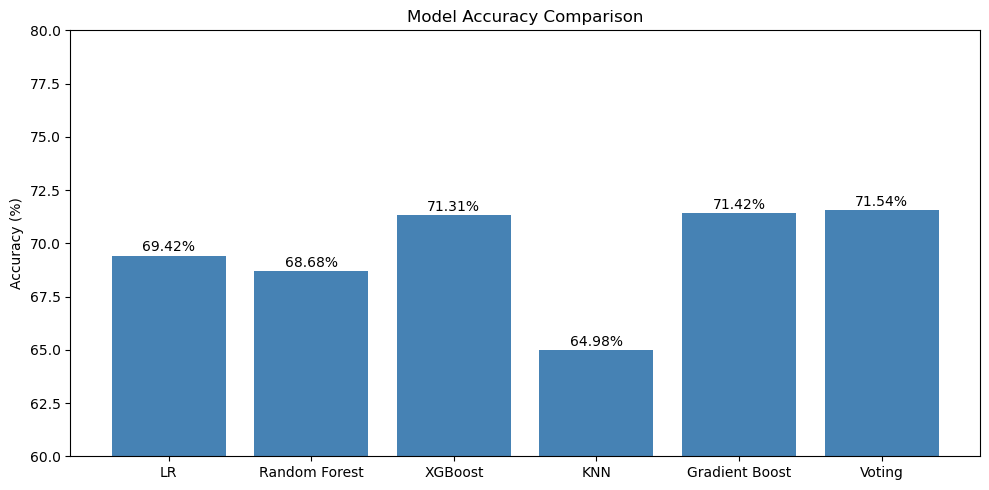

In [21]:
models     = ['LR', 'Random Forest', 'XGBoost', 'KNN', 'Gradient Boost', 'Voting']
accuracies = [
    accuracy_score(y_test, y_pred_lr)     * 100,
    accuracy_score(y_test, y_pred_rf)     * 100,
    accuracy_score(y_test, y_pred_xgb)    * 100,
    accuracy_score(y_test, y_pred_knn)    * 100,
    accuracy_score(y_test, y_pred_gb)     * 100,
    accuracy_score(y_test, y_pred_voting) * 100,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(models, accuracies, color='steelblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(60, 80)

# Har bar pe number likho
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.2,
             f'{acc:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

<h2>Target Distribution

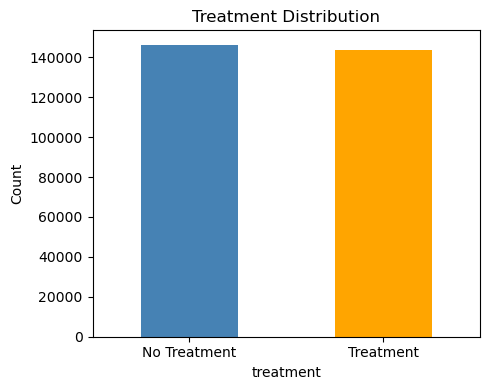

In [22]:
plt.figure(figsize=(5, 4))
df['treatment'].value_counts().plot(kind='bar', 
                                     color=['steelblue','orange'])
plt.title('Treatment Distribution')
plt.xticks([0, 1], ['No Treatment', 'Treatment'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<h2>Saving Model

In [27]:
import joblib

joblib.dump(voting_model, 'mental_health_model.pkl')
joblib.dump(scaler,       'scaler.pkl')

print("Models saved!")

Models saved!


In [29]:
import os
print("Model size:", round(os.path.getsize('mental_health_model.pkl') / 1024 / 1024, 2), "MB")
print("Scaler size:", round(os.path.getsize('scaler.pkl') / 1024 / 1024, 2), "MB")

Model size: 2.46 MB
Scaler size: 0.0 MB


In [30]:
import os
print(os.getcwd())  # yeh batayega pkl file kahan save hui hai

c:\ML\Classification\Mental Health
